In [1]:
# To import my files
import sys
import os

src = os.path.abspath("./src")

if src not in sys.path:
    sys.path.append(src)

In [2]:
# Imports
import torch
from tqdm import tqdm
from matplotlib import pyplot as plt

from src.model import PINNDiscovery
from src.physics import compute_pde_residual_discovery
from src.dataset import generate_noisy_data

In [3]:
# Parameters of the exp.

# Domain
X_MIN, X_MAX = -10.0, 10.0
T_MIN, T_MAX = 0.0, 1.0

# Number of observation points
N_OBS = 500

# Neural network architecture
LAYERS = [2, 20, 20, 20, 20, 20, 20, 20, 20, 1]

# Optimization hyperparameters
LEARNING_RATE = 1e-3
EPOCHS = 20000
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
# Fix seed
torch.manual_seed(151)

In [5]:
# Generate data
(x_data, t_data), u_obs = generate_noisy_data(N_OBS, X_MIN, X_MAX, T_MIN, T_MAX, DEVICE)

In [6]:
# Model
model = PINNDiscovery(LAYERS).to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

loss_history = []
lambdas_1_history = []
lambdas_2_history = []

In [7]:
# Train loop
model.train()

for _ in tqdm(range(1, EPOCHS + 1), desc="Train progress", unit=" Epoch"):
    optimizer.zero_grad()
    
    u_pred, f_pred = compute_pde_residual_discovery(model, t_data, x_data)
    
    loss_u = torch.mean((u_pred - u_obs)**2)
    loss_f = torch.mean(f_pred**2)
    
    loss = loss_u + loss_f
    
    loss.backward()
    optimizer.step()
    
    loss_history.append(loss.item())
    lambdas_1_history.append(model.lambda_1.item())
    lambdas_2_history.append(model.lambda_2.item())

Train progress:   0%|          | 0/20000 [00:00<?, ? Epoch/s]d:\Github\piml-learning-hub\env\Lib\site-packages\torch\autograd\graph.py:1072: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\Users\task_179069043315592\croot\libtorch_1790690594113\work\aten\src\ATen\cuda\CublasHandlePool.cpp:410.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
Train progress: 100%|██████████| 20000/20000 [06:56<00:00, 48.04 Epoch/s]


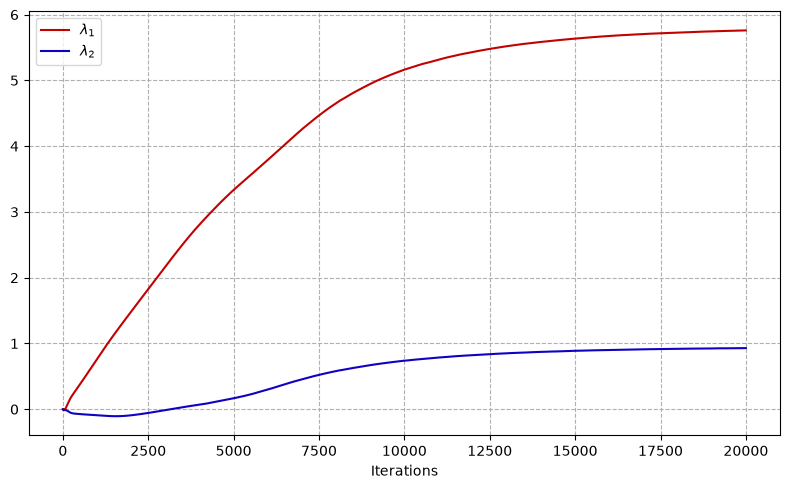

In [8]:
plt.figure(figsize=(8, 5))

plt.plot(lambdas_1_history, color="#c20202", label=r"$\lambda_1$")
plt.plot(lambdas_2_history, color="#0f02c2", label=r"$\lambda_2$")


plt.grid(True, which="both", ls="--")

plt.xlabel('Iterations')

plt.legend()
plt.tight_layout()

plt.show()

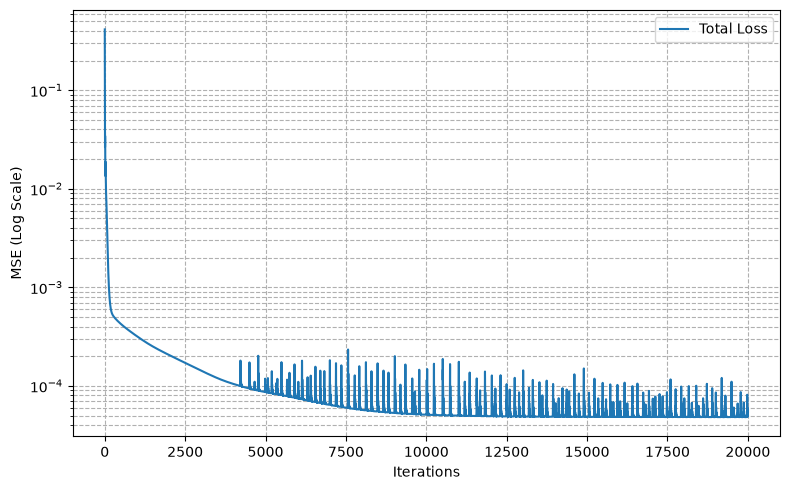

In [9]:
plt.figure(figsize=(8, 5))

plt.plot(loss_history, label='Total Loss')
plt.yscale('log')

plt.xlabel('Iterations')
plt.ylabel('MSE (Log Scale)')

plt.grid(True, which="both", ls="--")

plt.legend()
plt.tight_layout()

plt.show()